In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

I am loading in the file, and doing quick inspection to get familiar with the data.

In [3]:
data = pd.read_csv("data/raw/housing.csv")

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
print("Total number of rows: " + str(data.size))

Total number of rows: 206400


In [6]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Splitting dataset into training and test set

In [7]:

train_set, test_set = train_test_split(data, test_size=0.2, random_state=142)

In [8]:
train_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16349.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.576060,35.639528,28.660792,2650.587694,540.908435,1431.202519,502.041606,3.874176,207096.552447
std,2.002628,2.133772,12.614448,2215.597732,429.925960,1155.299540,389.803155,1.897529,115463.056370
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.940000,18.000000,1451.000000,297.000000,788.000000,281.000000,2.566950,119475.000000
50%,-118.510000,34.260000,29.000000,2136.000000,435.000000,1166.500000,410.000000,3.537500,180400.000000
75%,-118.010000,37.710000,37.000000,3152.250000,646.000000,1725.250000,603.000000,4.740400,265300.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
print("Missing Values per column:")
missing_values = pd.DataFrame({
    'Missing_Count': train_set.isnull().sum(),
    'Missing_%': (train_set.isnull().mean() * 100).round(2)
})

missing_columns = missing_values[missing_values['Missing_Count'] > 0]
print(missing_columns)

Missing Values per column:
                Missing_Count  Missing_%
total_bedrooms            163       0.99


Column total_bedrooms in training set contains 163 missing values, which is around 1% of all values in this column.

<Figure size 1000x1000 with 0 Axes>

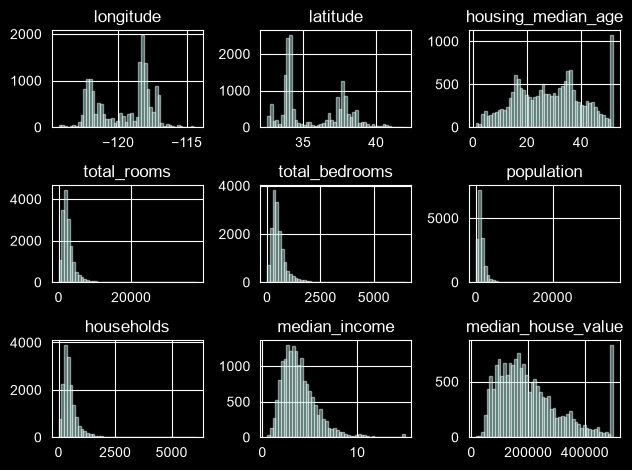

In [10]:
plt.figure(figsize=(10,10))
train_set.hist(alpha=0.5, bins=50)
plt.tight_layout()

## Handling total_bedrooms (skewness, missing values)

<Axes: >

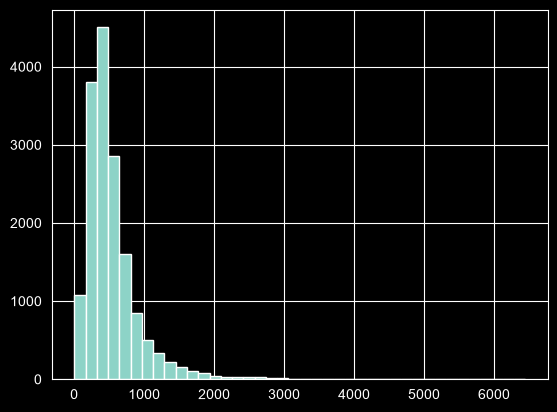

In [11]:
train_set['total_bedrooms'].hist(bins=40)

In [12]:
train_set.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        163
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

<Axes: >

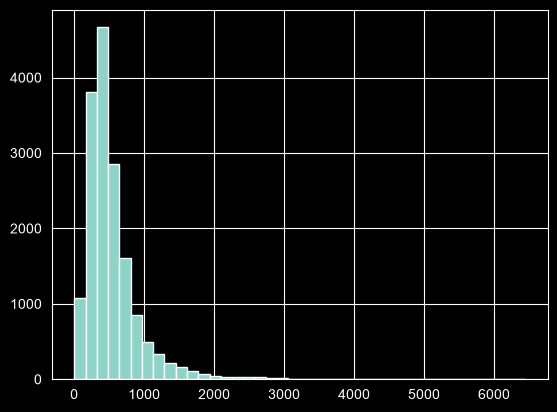

In [13]:
bedrooms_median_val = train_set['total_bedrooms'].median()
train_set.fillna({'total_bedrooms': bedrooms_median_val}, inplace=True)
train_set['total_bedrooms'].hist(bins=40)

In [14]:
q1, q3 = train_set['total_bedrooms'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = train_set[(train_set['total_bedrooms'] < q1 - 1.5 * iqr) | (train_set['total_bedrooms'] > q3 + 1.5 * iqr)]
print(f"Outlier count: {len(outliers)}")

Outlier count: 1078


In [15]:
invalid_rooms = train_set[train_set['total_bedrooms'] > train_set['total_rooms']]
print("Bedrooms > Total rooms count:", len(invalid_rooms))

Bedrooms > Total rooms count: 4


In [16]:
train_set_temp = train_set[train_set['total_bedrooms'] > train_set['total_rooms']].copy()
train_set_temp.head(6)
train_set = train_set[train_set['total_bedrooms'] <= train_set['total_rooms']].copy()

3.54372277271573
-0.9701971644338786


<Axes: >

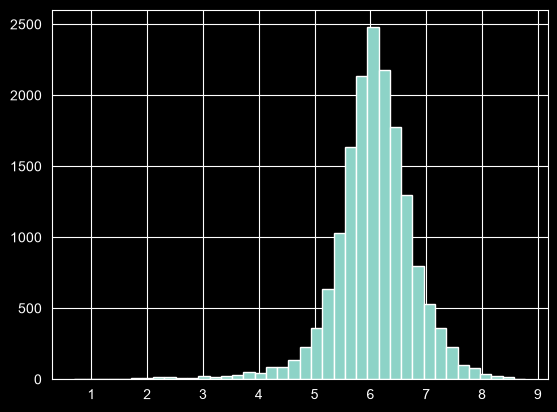

In [17]:
print(train_set['total_bedrooms'].skew())
train_set['log_total_bedrooms'] = np.log1p(train_set['total_bedrooms'])
print(train_set['log_total_bedrooms'].skew())

train_set['log_total_bedrooms'].hist(bins=40)

In [18]:
from sklearn.preprocessing import power_transform
train_set['yeo_total_bedrooms'] = power_transform(pd.DataFrame(train_set['total_bedrooms']),method='yeo-johnson',standardize=True)
print(train_set['yeo_total_bedrooms'].skew())

0.10799613570704916


<Axes: >

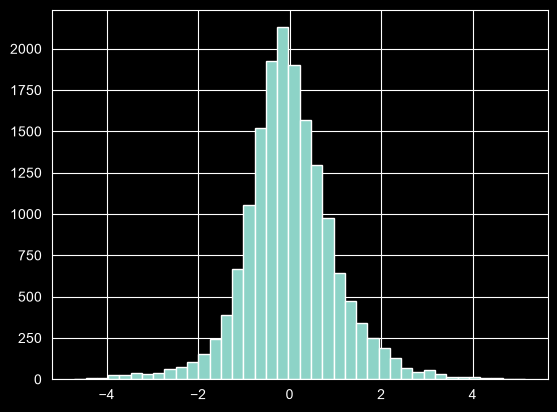

In [19]:
train_set['yeo_total_bedrooms'].hist(bins=40)

In [20]:
train_set['yeo_total_bedrooms'].kurtosis()
train_set['yeo_total_bedrooms'].describe()

count    1.650800e+04
mean     2.668624e-17
std      1.000030e+00
min     -4.706623e+00
25%     -5.701942e-01
50%     -4.829623e-02
75%      5.362626e-01
max      5.148011e+00
Name: yeo_total_bedrooms, dtype: float64

In [21]:
q1, q3 = train_set['yeo_total_bedrooms'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = train_set[(train_set['yeo_total_bedrooms'] < q1 - 1.5 * iqr) | (train_set['yeo_total_bedrooms'] > q3 + 1.5 * iqr)]
print(f"Outlier count: {len(outliers)}")

Outlier count: 705


# Target variable: median_house_value



<Axes: >

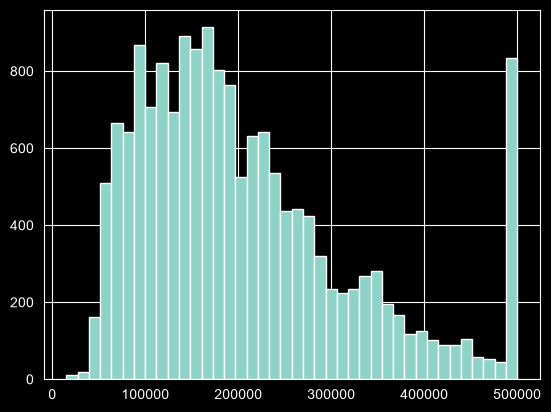

In [22]:
train_set['median_house_value'].hist(bins=40)

Capped data can influence the final predictions

In [23]:
limit = 500000
capped = (train_set['median_house_value'] >= limit).sum()
print("% of rows capped: " + str((capped/len(train_set))*100))

% of rows capped: 4.821904531136418


The capped values represent less than 5% of the entire training dataset so I decided to drop them

In [24]:
train_set = train_set[train_set['median_house_value'] < limit].copy()

<Axes: >

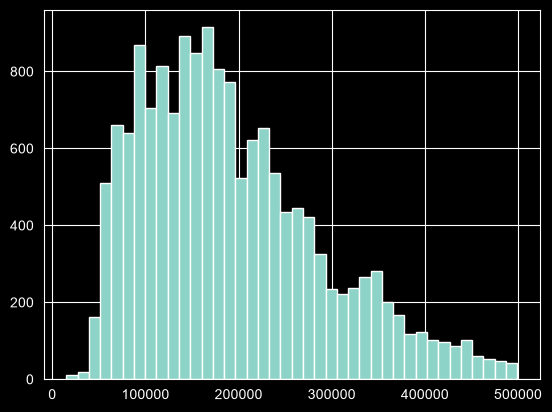

In [25]:
train_set['median_house_value'].hist(bins=40)

0.7852428859674238
-0.0240422586816676


<Axes: >

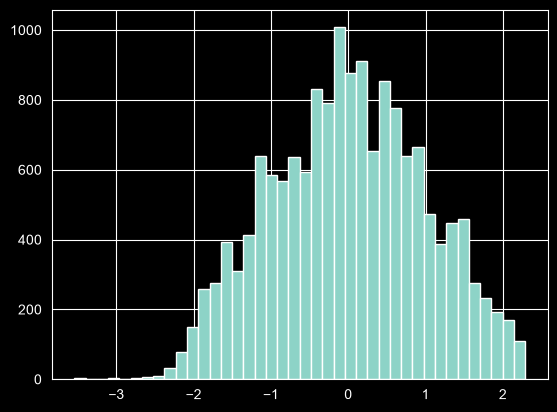

In [26]:
print(train_set['median_house_value'].skew())
from sklearn.preprocessing import power_transform
train_set['box_median_house_value'] = power_transform(pd.DataFrame(train_set['median_house_value']),method='box-cox',standardize=True)
print(train_set['box_median_house_value'].skew())
train_set['box_median_house_value'].hist(bins=40)

## Total rooms

<Axes: >

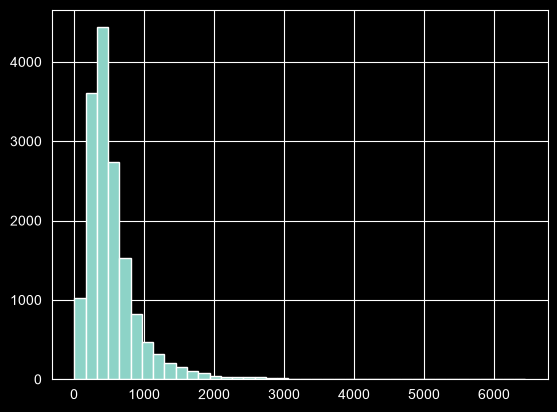

In [27]:
train_set['total_bedrooms'].hist(bins=40)

In [28]:
(train_set['total_rooms'] <= 0).sum()

np.int64(0)

There are no 0 or negative numbers of rooms

0.11904571704322899


<Axes: >

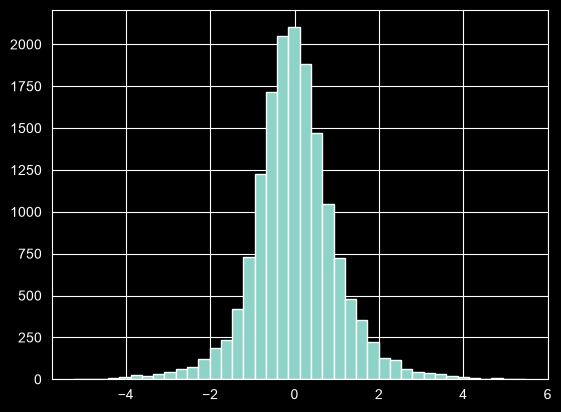

In [29]:
train_set['total_rooms'].skew()
train_set['box_total_rooms'] = power_transform(pd.DataFrame(train_set['total_rooms']),method='box-cox',standardize=True)
print(train_set['box_total_rooms'].skew())
train_set['box_total_rooms'].hist(bins=40)

## Housing median age

<Axes: >

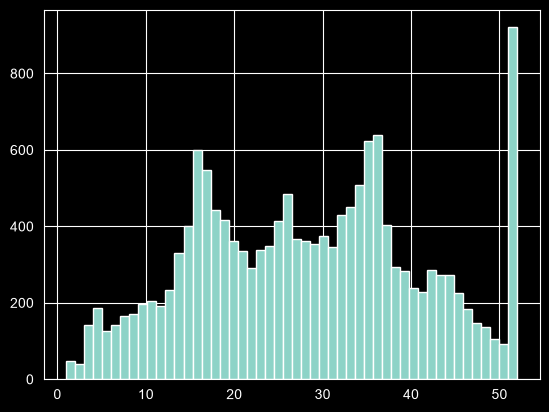

In [30]:
train_set['housing_median_age'].hist(bins=50)

applying binning to remove to better integrate the capped values

<Axes: xlabel='age_category', ylabel='count'>

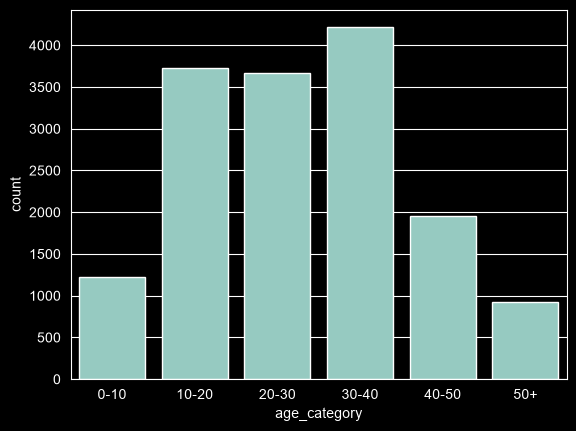

In [31]:
train_set['age_category'] = pd.cut(
    train_set['housing_median_age'],
    bins=[0,10,20,30,40,50,float('inf')],
    labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50+'])

import seaborn as sns
sns.countplot(data=train_set, x='age_category')

In [32]:
train_set = pd.get_dummies(
    train_set,
    columns=['age_category'],
    prefix='age',
    drop_first=True,
    dtype=int
)

In [33]:
train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,log_total_bedrooms,yeo_total_bedrooms,box_median_house_value,box_total_rooms,age_10-20,age_20-30,age_30-40,age_40-50,age_50+
17758,-121.80,37.35,17.0,2529.0,423.0,1756.0,429.0,5.1017,240700.0,<1H OCEAN,6.049733,-0.088331,0.644352,0.216394,1,0,0,0,0
10223,-117.89,33.88,27.0,2091.0,336.0,1037.0,332.0,5.7519,243400.0,<1H OCEAN,5.820083,-0.409075,0.667405,-0.054045,0,1,0,0,0
17443,-120.47,34.66,4.0,3376.0,525.0,1684.0,535.0,4.9237,166600.0,NEAR OCEAN,6.265301,0.227019,-0.082682,0.647881,0,0,0,0,0
12965,-121.32,38.70,17.0,3214.0,551.0,1879.0,562.0,4.3643,124900.0,INLAND,6.313548,0.299557,-0.608965,0.572610,1,0,0,0,0
20149,-119.12,34.38,28.0,7200.0,1281.0,3793.0,1238.0,4.0750,237900.0,<1H OCEAN,7.156177,1.691282,0.620236,1.908398,0,1,0,0,0


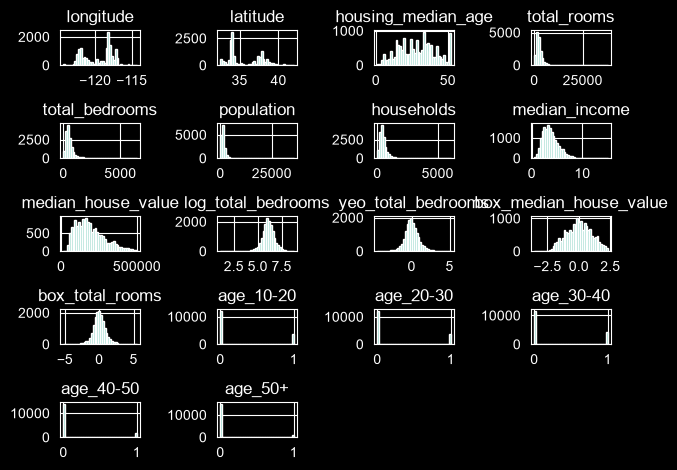

In [34]:
train_set.hist(bins=40)
plt.tight_layout()

Transforming per block ratios to per household ratios

In [35]:
train_set['population_per_household'] = train_set['population']/train_set['households']
train_set['rooms_per_household'] = train_set['total_rooms']/train_set['households']
train_set['bedrooms_per_room'] = train_set['total_bedrooms']/train_set['total_rooms']


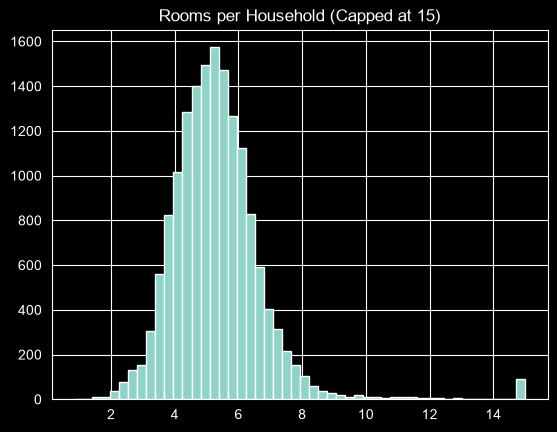

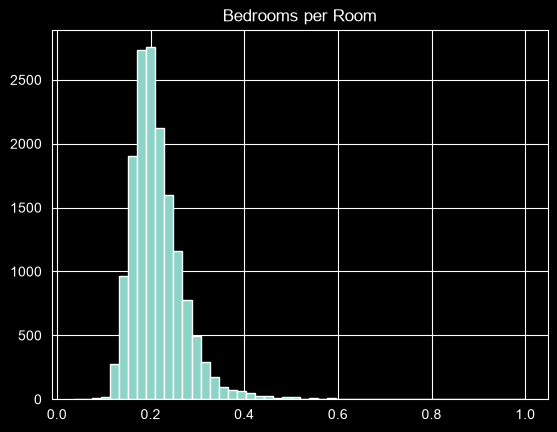

In [36]:
train_set['rooms_per_household'].clip(upper=15).hist(bins=50)
plt.title("Rooms per Household (Capped at 15)")
plt.show()

train_set['bedrooms_per_room'].hist(bins=50)
plt.title("Bedrooms per Room")
plt.show()

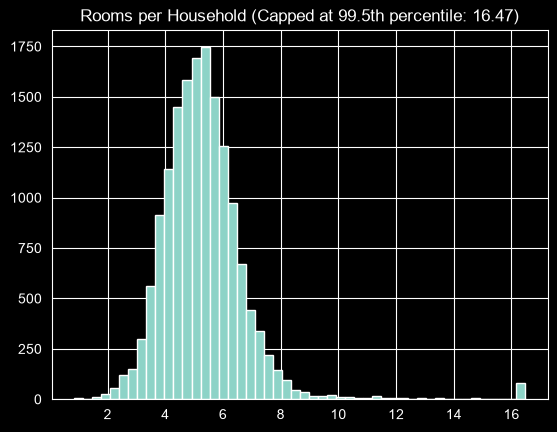

In [37]:

upper_limit = train_set['rooms_per_household'].quantile(0.995)
train_set['rooms_per_household_capped'] = train_set['rooms_per_household'].clip(upper=upper_limit)

train_set['rooms_per_household_capped'].hist(bins=50)
plt.title(f"Rooms per Household (Capped at 99.5th percentile: {upper_limit:.2f})")
plt.show()

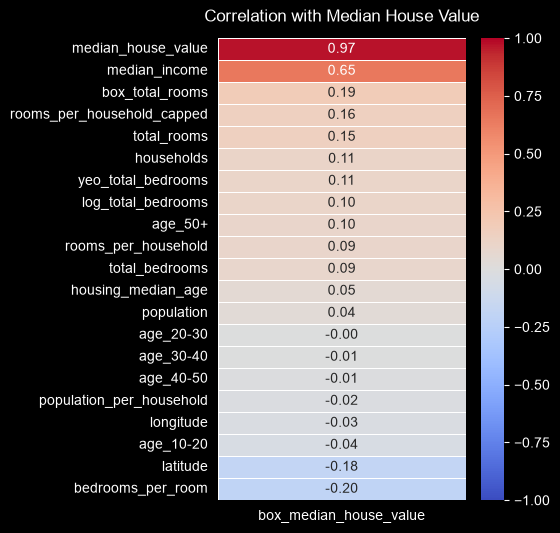

In [38]:
target_corr = train_set.corr(numeric_only=True)[['box_median_house_value']].drop('box_median_house_value')
target_corr = target_corr.sort_values(by='box_median_house_value', ascending=False)

# 2. Plot single-column heatmap
plt.figure(figsize=(4, 6))
sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    cbar=True,
    linewidths=0.5
)
plt.title("Correlation with Median House Value", pad=12)
plt.show()

In [40]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 15712 entries, 17758 to 277
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   15712 non-null  float64
 1   latitude                    15712 non-null  float64
 2   housing_median_age          15712 non-null  float64
 3   total_rooms                 15712 non-null  float64
 4   total_bedrooms              15712 non-null  float64
 5   population                  15712 non-null  float64
 6   households                  15712 non-null  float64
 7   median_income               15712 non-null  float64
 8   median_house_value          15712 non-null  float64
 9   ocean_proximity             15712 non-null  str    
 10  log_total_bedrooms          15712 non-null  float64
 11  yeo_total_bedrooms          15712 non-null  float64
 12  box_median_house_value      15712 non-null  float64
 13  box_total_rooms             15712 non-null  f